In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%load_ext autoreload
%autoreload 2

import main_1f as m1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


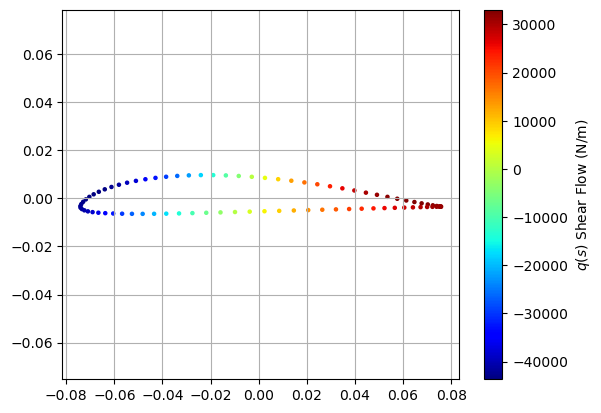

In [5]:
# Plot of Shear Flow from Previous Code
qs_t, dx_t, dy_t = m1.shearflow_calc(0, 1000)

plt.scatter(m1.xmt_c, m1.ymt_c, c=qs_t, cmap='jet', s=5)
plt.axis('equal')
plt.colorbar(label=r'$q(s)$ Shear Flow (N/m)')
plt.grid()
plt.show()

In [6]:
# Calculating Shear Center (X Coordinate)
qs_01, dx_01, dy_01 = m1.shearflow_calc(0, 1)

# plt.scatter(m1.xmt_c, m1.ymt_c, c=qs_01, cmap='jet', s=5)
# plt.axis('equal')
# plt.colorbar(label=r'$q(s)$ Shear Flow (N/m)')
# plt.grid()
# plt.show()

e2_c = np.sum(qs_01*(dy_01*m1.xmt_c -dx_01*m1.ymt_c))
print("e2 (centroidal):", e2_c)

e2 (centroidal): -0.034802290982741145


In [7]:
# Calculating Shear Center (Y Coordinate)
qs_10, dx_10, dy_10 = m1.shearflow_calc(1, 0)

# plt.scatter(m1.xmt_c, m1.ymt_c, c=qs_10, cmap='jet', s=5)
# plt.axis('equal')
# plt.colorbar(label=r'$q(s)$ Shear Flow (N/m)')
# plt.grid()
# plt.show()

e3_c = np.sum(qs_10*(dy_10*m1.xmt_c -dx_10*m1.ymt_c))
print("e3 (centroidal):", e3_c)

e3 (centroidal): -0.002954598780087806


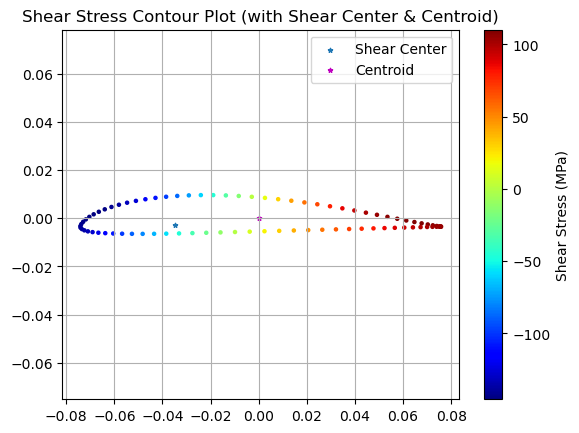

In [8]:
# Plot of Shear Center with Centroid (Shear Stress)
plt.scatter(m1.xmt_c, m1.ymt_c, c=(qs_t/m1.ta*1e-6), cmap='jet', s=5)
plt.colorbar(label='Shear Stress (MPa)')

# Shear Center and Centroid
plt.scatter(e2_c, e3_c, marker='*', label='Shear Center', s=10)
plt.scatter(0, 0, marker='*', c='m', label='Centroid', s=10)

plt.title("Shear Stress Contour Plot (with Shear Center & Centroid)")
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

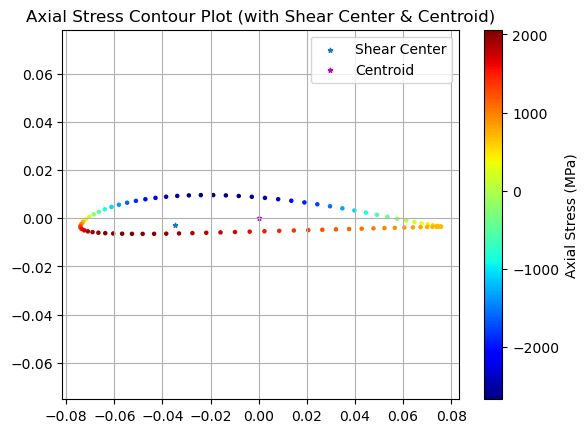

In [9]:
# Plot of Shear Center with Centroid (Axial Stress)

S11_r = m1.axialstress_calc(-920, 0)

plt.scatter(m1.xmt_c, m1.ymt_c, c=(S11_r*1e-6), cmap='jet', s=5)
plt.colorbar(label='Axial Stress (MPa)')

# Shear Center and Centroid
plt.scatter(e2_c, e3_c, marker='*', label='Shear Center', s=10)
plt.scatter(0, 0, marker='*', c='m', label='Centroid', s=10)

plt.title("Axial Stress Contour Plot (with Shear Center & Centroid)")
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

In [10]:
# Coordinates of Shear Center & Centroid
c = np.array([m1.x_c, m1.y_c])

sc_c = np.array([e2_c, e3_c])
sc = c + sc_c

print("Centroid (Leading Edge):", c)
print("Shear Center (Centroid):", sc_c)
print("Shear Center (Leading Edge):", sc)

Centroid (Leading Edge): [0.07421297 0.00347863]
Shear Center (Centroid): [-0.03480229 -0.0029546 ]
Shear Center (Leading Edge): [0.03941068 0.00052403]


In [11]:
j = 0

x_m = np.concatenate((np.array([(m1.xle + m1.xu[0])/2]), m1.xmu, np.array([(m1.xte + m1.xu[-1])/2])), axis=0)

y_mu = np.concatenate((np.array([(m1.yle + m1.yu[0])/2]), m1.ymu, np.array([(m1.yte + m1.yu[-1])/2])), axis=0)
y_ml = np.concatenate((np.array([(m1.yle + m1.yl[0])/2]), m1.yml, np.array([(m1.yte + m1.yl[-1])/2])), axis=0)


while(x_m[j] < sc[0]):
    j += 1

xk = x_m[j-1]
print(xk, j)

0.03573224999999999 13


In [12]:
dyu = dy_t[:m1.nh]
dyu = dyu[::-1]
dyl = dy_t[m1.nh:]

qsu_t = qs_t[:m1.nh]
qsu_t = qsu_t[::-1]
qsl_t = qs_t[m1.nh:]


dV = np.zeros_like(qsu_t)
V_t = m1.V3j

for i in range(len(x_m)):
    dV[i] = qsu_t[i]*dyu[i] + qsl_t[i]*dyl[i]

    if i == j:
        dV[i] -= V_t

V = np.cumsum(dV)

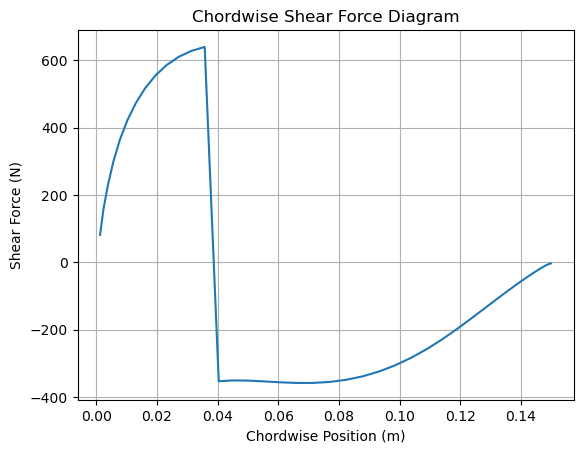

In [13]:
# print(V.shape, x_m.shape)
plt.plot(x_m, V)
plt.title("Chordwise Shear Force Diagram")
plt.xlabel("Chordwise Position (m)")
plt.ylabel("Shear Force (N)")
plt.grid()
plt.show()

In [14]:
c_m = (y_mu + y_ml)/2
dxu = dx_t[:m1.nh]
dxu = dxu[::-1]
dxl = dx_t[m1.nh:]

M = np.zeros_like(qsu_t)

for i in range(len(x_m)):

    for l in range(i):

        pu = np.cross(np.array([x_m[l]-x_m[i], y_mu[l]-c_m[i]]), np.array([dxu[l], dyu[l]]))
        pl = np.cross(np.array([x_m[l]-x_m[i], y_ml[l]-c_m[i]]), np.array([dxl[l], dyl[l]]))

        M[i] += -qsu_t[l]*pu - qsl_t[l]*pl

    if i >= j:

        p = sc[0]-x_m[i]
        M[i] += V_t*p


ValueError: operands could not be broadcast together with shapes (40,) (41,) 

In [15]:
plt.plot(x_m, M)
plt.title("Chordwise Bending Moment Diagram")
plt.xlabel("Chordwise Position (m)")
plt.ylabel("Bending Moment (Nm)")
plt.grid()
plt.show()

NameError: name 'M' is not defined

In [ ]:
# from scipy.integrate import cumulative_trapezoid

# qsu_t = qsu_t
# dyu = dyu
# dx = dx_t[m1.nh:]

# dVdx = qsu_t*dyu/dx + qsl_t*dyl/dx
# V_ = cumulative_trapezoid(dVdx, x_m, initial=0)
# V_[x_m >= sc[0]] -= 1000

# plt.plot(x_m, V_)
# plt.grid()

In [ ]:
cm = np.concatenate((np.array([m1.yle]), (m1.yu + m1.yl)/2, np.array([m1.yte])))
h = np.concatenate((np.array([m1.yle]), (m1.yu - m1.yl)/2, np.array([m1.yte])))

h_m = (y_mu - y_ml)/2
x_t = np.concatenate((np.array([m1.xle]), m1.xu, np.array([m1.xte])))


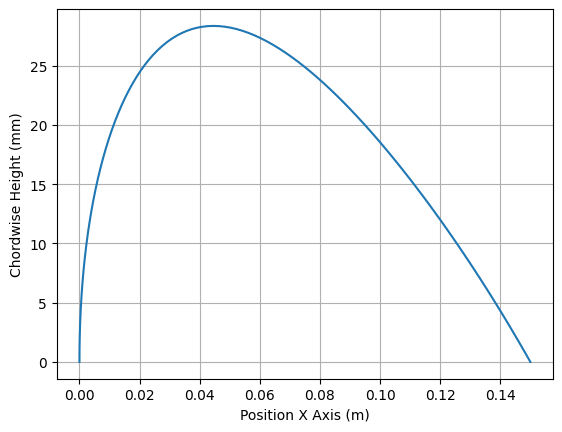

In [ ]:
# Chordwise Height Distribution of Airfoil

plt.plot(x_t, 2*h*1e3)
plt.grid()
plt.ylabel("Chordwise Height (mm)")
plt.xlabel("Position X Axis (m)")
plt.show()

In [ ]:
# print(V.shape, h_m.shape)

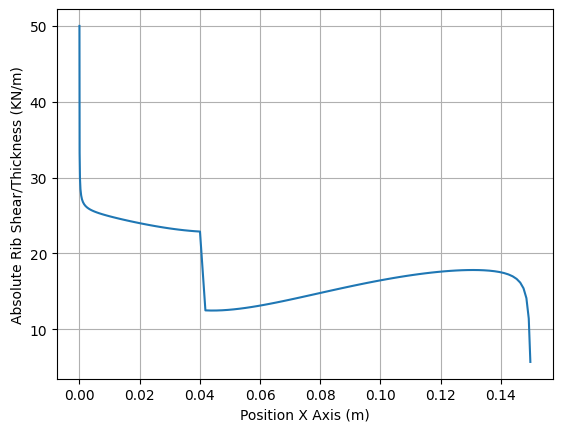

In [ ]:
# Shear Force per Unit Length

Vl = V/(2*h_m)

plt.plot(x_m, np.abs(Vl*1e-3))
plt.ylabel("Absolute Rib Shear/Thickness (KN/m)")
plt.xlabel("Position X Axis (m)")
plt.grid()

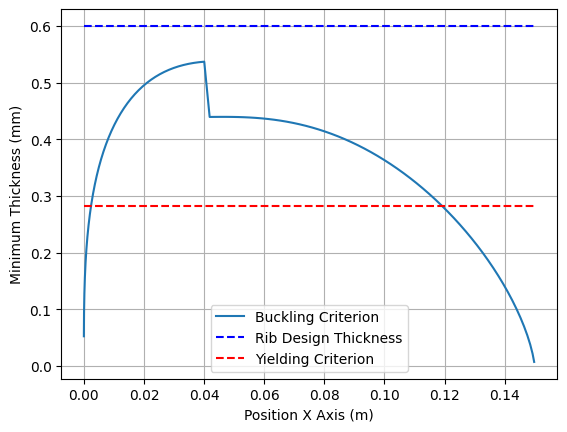

In [ ]:
# Estimating the Web Thickness
# Nxy is the Critical In Plane Shear Load per Unit Length

fs = 3
Nxy = np.abs(fs*Vl)

K = (5.35*np.pi**2*m1.Ey)/(12*(1 - m1.nu**2))
th_r_min_b = np.cbrt(Nxy*(2*h_m)**2/K)


Sy = 500e6
tauy = Sy/np.sqrt(3)

# qs_max = np.max(qs_t)
# th_r_min_sy = qs_max/(tauy/fs)

th_r_min_sy = np.max(np.abs(Vl[5:]))/(tauy/fs)

th_rd_web = 0.6*1e-3

plt.plot(x_m, th_r_min_b*1e3, label='Buckling Criterion')
xlin = np.linspace(0, 0.15, 100)
plt.plot(xlin, np.ones_like(xlin)*th_rd_web*1e3, 'b--', label='Rib Design Thickness')
plt.plot(xlin, np.ones_like(xlin)*th_r_min_sy*1e3, 'r--', label='Yielding Criterion')
plt.grid()
plt.legend()
plt.ylabel("Minimum Thickness (mm)")
plt.xlabel("Position X Axis (m)")
plt.show()

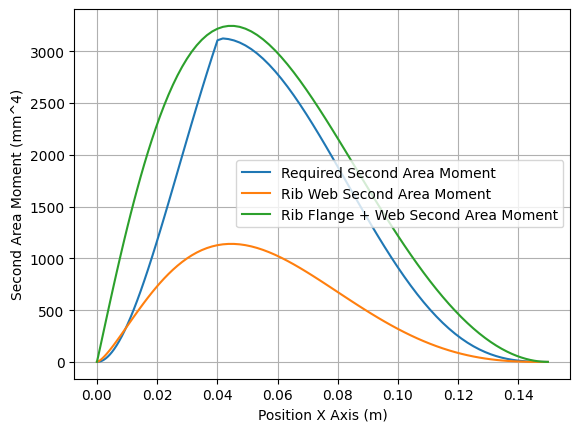

In [ ]:
# Rib Flange Design

I_req = np.abs(M*(h_m)/(Sy/fs))
I_web = th_rd_web*(2*h_m)**3/12
A_req_flange = 0.5*(I_req-I_web)/(h_m)**2
A_req_max = 0.6*np.max(A_req_flange)
I_calc = I_web + 2*(A_req_max)*(h_m)**2

plt.plot(x_m, I_req*1e12, label='Required Second Area Moment')
plt.plot(x_m, I_web*1e12, label='Rib Web Second Area Moment')
plt.plot(x_m, I_calc*1e12, label='Rib Flange + Web Second Area Moment')
plt.legend()
plt.ylabel("Second Area Moment (mm^4)")
plt.xlabel("Position X Axis (m)")
plt.grid()
plt.show()

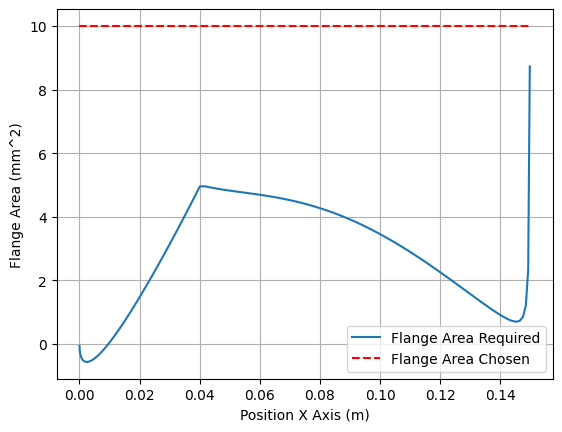

In [ ]:
plt.plot(x_m, A_req_flange*1e6, label='Flange Area Required')
plt.plot(xlin, np.ones_like(xlin)*10, 'r--', label='Flange Area Chosen')
plt.ylabel("Flange Area (mm^2)")
plt.xlabel("Position X Axis (m)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Spar Design

Sy_a = Sy/fs

h_max = np.max(h_m)
idx_hmax = np.argmax(h_m)

th_fd_web = th_rd_web
A_spar_flange_arr = np.linspace(0, 300, 301)

I22_sw = (th_fd_web*(2*h_max)**3/12) + (th_fd_web*(2*h_max)*(c_m[idx_hmax]-sc[1])**2)
I22_sAf = (A_spar_flange_arr*(y_mu[idx_hmax]-c[1])**2 + A_spar_flange_arr*(y_ml[idx_hmax]-c[1])**2)*1e-6

I22_with_spar = I22_sw + I22_sAf + m1.I22

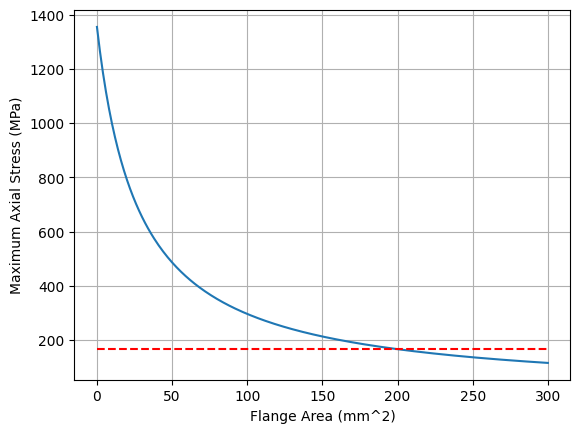

In [ ]:
S11_with_spar = np.zeros_like(A_spar_flange_arr)

Xmat = np.array([y_mu[idx_hmax]-sc[1], -x_m[idx_hmax]+sc[0]])
Mmat = np.array([m1.M2r, 0]).T

for i in range(len(A_spar_flange_arr)):
    Imat_spar = np.array([[m1.I33, m1.I23], 
                          [m1.I23, I22_with_spar[i]]])
    I_eqv_spar = 1/(I22_with_spar[i]*m1.I33 - m1.I23**2)

    S11_with_spar[i] = (Xmat @ Imat_spar @ Mmat)*I_eqv_spar

plt.plot(A_spar_flange_arr, np.abs(S11_with_spar)*1e-6, label='Maximum Axial Stress')
plt.plot(A_spar_flange_arr, np.ones_like(A_spar_flange_arr)*Sy_a*1e-6, 'r--')
plt.grid()
plt.xlabel("Flange Area (mm^2)")
plt.ylabel("Maximum Axial Stress (MPa)")
plt.show()

In [ ]:
A_sf_total = 2*200e-6

In [ ]:
'''
Upper Spar Flange Area = 200 mm^2
Lower Spar Flange Area = 200 mm^2

Thickness Spar Flange = 8 mm
Length of Spar Flange = 25 mm

Thickness of Spar Web = Thickness of Rib Web = 0.6 mm

Area of Upper Rib Flange = 10 mm^2
Area of Lower Rib Flange = 10 mm^2

Thickness of Rib Flange = 1 mm 
Length of RIb Flange = 10 mm

'''

'\nUpper Spar Flange Area = 200 mm^2\nLower Spar Flange Area = 200 mm^2\n\nThickness Spar Flange = 8 mm\nLength of Spar Flange = 25 mm\n\nThickness of Spar Web = Thickness of Rib Web = 0.6 mm\n\nArea of Upper Rib Flange = 10 mm^2\nArea of Lower Rib Flange = 10 mm^2\n\nThickness of Rib Flange = 1 mm \nLength of RIb Flange = 10 mm\n\n\n'

In [ ]:
print(x_m[idx_hmax])

0.0436878
